In [1]:
import rasterio as rio
import geopandas as gpd
from glob import glob
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np
import seaborn as sns
import re
import os
import pandas as pd

In [14]:

LEGEND_CLASSES = {
    0: 'Nodata',
    1: 'Open Water',
    # 2: 'Impervious (raised structures)',
    2: 'Impervious Structures',
    # 3: 'Impervious (paved surfaces)',
    3: 'Impervious Surfaces',
    4: 'Barren Land',
    5: 'Tree Canopy/Woody Vegetation',
    6: 'Low Vegetation/Herbaceous',
    7: 'Cultivated Crops',
    8: 'Unclassified',
}

centroid_data = []
project_crs = None
histograms = {}
num_classes = 8

for split in range(4):
    histograms[split] = np.zeros(num_classes, dtype=np.int64)
    for path in glob(f'../data/splits/split_{split+1}/target/*.tif'):
        try:
            with rio.open(path) as src:
                if project_crs is None:
                    project_crs = src.crs

                bounds = src.bounds
                centroid_x = (bounds.left + bounds.right) / 2
                centroid_y = (bounds.bottom + bounds.top) / 2
                centroid_geom = Point(centroid_x, centroid_y)

                arr = src.read(1)
                if src.nodata is not None:
                    valid_mask = arr != src.nodata
                else:
                    # if nodata not defined, exclude zeros if 0==Nodata in your legend
                    valid_mask = arr != 0

                valid_pixels = arr[valid_mask].astype(np.int64)
            
                record = {
                    'split': split, 'source_file': path, 'geometry': centroid_geom,
                }
                
                raster_hist, _ = np.histogram(valid_pixels, bins=range(1, num_classes + 2))
                histograms[split] += raster_hist
                
                total_valid_pixels = np.sum(raster_hist)
    
                for i, count in enumerate(raster_hist):
                    class_id = i + 1
                    
                    # Get the descriptive name from your dictionary
                    class_name = LEGEND_CLASSES.get(class_id, f'Class_{class_id}')
                    
                    # Sanitize the name for use as a column header
                    # Replaces spaces and slashes with underscores
                    safe_col_name = re.sub(r'[\s/]+', '_', class_name)
                    
                    # Add data with the new descriptive name
                    # record[f'{safe_col_name}_ct'] = count
                    if total_valid_pixels > 0:
                        record[f'{safe_col_name}_pct'] = (count / total_valid_pixels) * 100
                    else:
                        record[f'{safe_col_name}_pct'] = 0

                centroid_data.append(record)

        except rio.errors.RasterioIOError as e:
            print(f"Error opening or reading {path}: {e}")
            continue

gdf = gpd.GeoDataFrame(centroid_data, crs=project_crs).to_crs(4326)
# gdf.to_file('../data/sampling_sites/sampling_sites.shp')

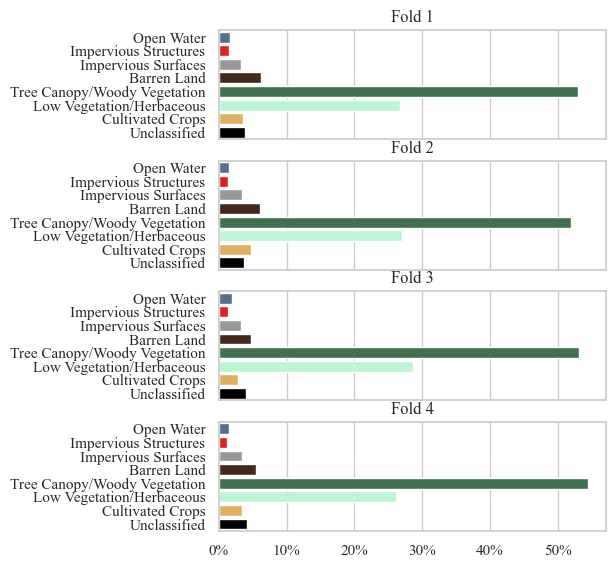

In [15]:
import matplotlib.ticker as mticker # Import the ticker module


LEGEND_COLORS_HEX = {
    0: '#ffffff',
    1: '#516c97',
    # 2: '#989899',
    2: '#FF0000',
    # 3: '#ffffff',
    3: '#989899',
    4: '#4a2514',
    5: '#37784e',
    6: '#b3fdd6',
    7: '#f6b44c',
    8: '#000000',
}

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'times new roman'

fig, axes = plt.subplots(4, 1, figsize=(5, 6.5), sharex=True, sharey=True)
class_labels = [v for k, v in LEGEND_CLASSES.items() if k != 0]
custom_colors = [LEGEND_COLORS_HEX[i] for i in range(1, 9)]

for i, ax in enumerate(axes.flatten()):
    sns.barplot(y=class_labels, x=(histograms[i] / histograms[i].sum()) * 100, ax=ax, palette=custom_colors, hue=class_labels)
    # ax.set_xscale('log')
    ax.xaxis.set_major_locator(mticker.FixedLocator([0, 10, 20, 30, 40, 50]))
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title(f'Fold {i+1}')
    # ax.set_xlim(left=0.1, right=100)
    # ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# fig.tight_layout()
# plt.savefig('../paper/images/fold_distributions.png', dpi=400)

c:\Users\dh2306\projects\ms-land-cover\.env\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\dh2306\projects\ms-land-cover\.env\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\dh2306\projects\ms-land-cover\.env\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

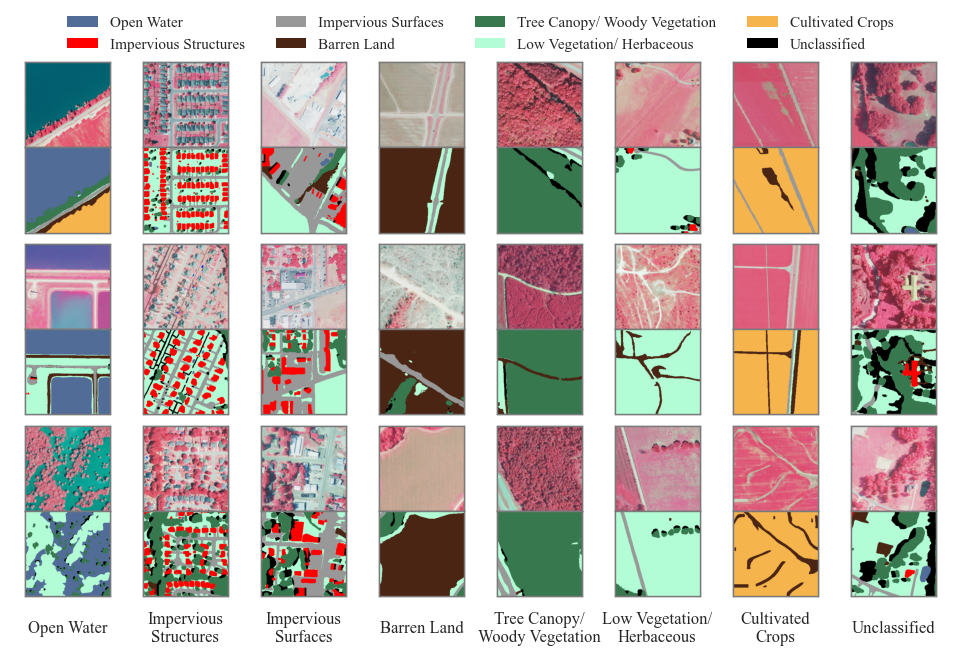

In [41]:
from matplotlib.patches import Patch

# sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'times new roman'

LEGEND_COLORS_HEX = {
    0: '#ffffff', 1: '#516c97', 2: '#FF0000', 3: '#989899',
    4: '#4a2514', 5: '#37784e', 6: '#b3fdd6', 7: '#f6b44c', 8: '#000000',
}

LEGEND_CLASSES = {
    0: 'Nodata',
    1: 'Open Water',
    # 2: 'Impervious (raised structures)',
    2: 'Impervious\nStructures',
    # 3: 'Impervious (paved surfaces)',
    3: 'Impervious\nSurfaces',
    4: 'Barren Land',
    5: 'Tree Canopy/\nWoody Vegetation',
    6: 'Low Vegetation/\nHerbaceous',
    7: 'Cultivated\nCrops',
    8: 'Unclassified',
}

def hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

palette_rgb = {k: hex_to_rgb(v) for k, v in LEGEND_COLORS_HEX.items()}
max_lbl = max(palette_rgb.keys())

from rasterio.warp import reproject, Resampling

def colorize_labels(arr, palette, max_label):
    arr_safe = np.clip(arr, 0, max_label).astype(np.int64)
    cmap = np.zeros((max_label + 1, 3), dtype=np.uint8)
    for lbl, col in palette.items():
        if lbl <= max_label:
            cmap[lbl] = col
    return cmap[arr_safe]

def read_aligned_rgb_and_label(target_path, input_path, palette_rgb, max_lbl):
    with rio.open(target_path) as tgt:
        lbl = tgt.read(1)
        tgt_transform = tgt.transform
        tgt_crs = tgt.crs
        height, width = lbl.shape
        nodata = tgt.nodata

    if nodata is not None:
        lbl_safe = np.where(lbl == nodata, 0, lbl)
    else:
        lbl_safe = lbl
    color_lbl = colorize_labels(lbl_safe, palette_rgb, max_lbl).astype(np.uint8)

    if input_path is None or not os.path.exists(input_path):
        return lbl_safe, color_lbl, None

    with rio.open(input_path) as src_i:
        try:
            # prefer (4,1,2) if present (false color), else (1,2,3), else replicate single band
            if src_i.count >= 4:
                arr = src_i.read((4, 1, 2))
            elif src_i.count >= 3:
                arr = src_i.read((1, 2, 3))
            else:
                arr = np.repeat(src_i.read(1)[None, ...], 3, axis=0)
        except Exception:
            if src_i.count >= 3:
                arr = src_i.read((1, 2, 3))
            else:
                arr = np.repeat(src_i.read(1)[None, ...], 3, axis=0)

        img_disp = np.moveaxis(arr, 0, 2).astype('float32')
        if img_disp.max() > 1.1:
            img_disp = np.clip(img_disp, 0, 255) / 255.0
        else:
            img_disp = np.clip(img_disp, 0.0, 1.0)

    return lbl_safe, color_lbl, img_disp

# grid plotting: select samples across all splits (rows = top n samples per class)
classes = [k for k in LEGEND_CLASSES.keys() if k != 0]
n_rows = 3           # number of samples (rows) to show per class
n_cols = len(classes)

ignore_ids = [
    '1172689',
    '1971322',
    '1571231',
    '1742973',
    '0863527',
]

gdf['id'] = gdf['source_file'].map(lambda x: os.path.basename(x).removesuffix('.tif'))

# sanitized names used earlier when building centroid_data
safe_names = {cid: re.sub(r'[\s/]+', '_', LEGEND_CLASSES[cid]) for cid in classes}

DOMINANCE_PCT = 90.0   # skip tiles with >= this percent for the class
MAX_CANDIDATES = 200   # examine up to this many top-ranked precomputed candidates

# layout: each cell is a 2x1 subgrid (input above label) with no gap, but gap between sample rows
fig2 = plt.figure(figsize=(n_cols * 1.2, n_rows * 2.0))
height_ratios = [1.0] * n_rows + [0.25]
gs = fig2.add_gridspec(n_rows + 1, n_cols, height_ratios=height_ratios, hspace=0.08, wspace=0.03)

labels = [LEGEND_CLASSES[i].replace('\n', ' ') for i in range(1, 9)]
colors = [LEGEND_COLORS_HEX[i] for i in range(1, 9)]
handles = [Patch(facecolor=c, edgecolor='none') for c in colors]

# place single-row legend centered above the axes
fig2.legend(handles, labels, loc='upper center', ncol=4,
            bbox_to_anchor=(0.5, 1.09), frameon=False, fontsize=11)

title_axes = []
for j, cid in enumerate(classes):
    ax_t = fig2.add_subplot(gs[-1, j])   # <-- use last row for titles
    ax_t.axis('off')
    ax_t.text(0.5, 0.5, LEGEND_CLASSES[cid], ha='center', va='center',
              fontsize=12, wrap=True, family=plt.rcParams['font.family'])
    title_axes.append(ax_t)

for j, cid in enumerate(classes):
    pct_col = f"{safe_names[cid]}_pct"
    candidates = gdf.loc[~gdf['id'].isin(ignore_ids)]
    
    # Primary: use precomputed column if available
    ranked = []
    if pct_col in candidates.columns:
        candidates[pct_col] = pd.to_numeric(candidates.get(pct_col), errors='coerce')
        ranked_df = candidates.dropna(subset=[pct_col]).sort_values(pct_col, ascending=False).head(MAX_CANDIDATES)
        # keep rows to consider (we'll filter by DOMINANCE_PCT below)
        ranked = list(ranked_df.to_dict('records'))

    # Fallback: if no ranked candidates from precomputed column, use entire gdf as candidate pool
    if not ranked:
        ranked = list(candidates.to_dict('records'))

    # Now select up to n_rows tiles with pct < DOMINANCE_PCT.
    chosen = []
    # 1) Try the precomputed pct values first (if present)
    for r in ranked:
        if len(chosen) >= n_rows:
            break
        pct_val = r.get(pct_col) if pct_col in r else None
        if pct_val is not None:
            try:
                if float(pct_val) < DOMINANCE_PCT:
                    chosen.append(r)
                else:
                    continue
            except Exception:
                continue

    # 2) If not enough chosen, compute pct from label files on remaining candidates (stop when we have enough)
    if len(chosen) < n_rows:
        # iterate over gdf rows not already chosen
        seen_paths = {c['source_file'] for c in chosen}
        for _, row in gdf.iterrows():
            if len(chosen) >= n_rows:
                break
            sf = row['source_file']
            if sf in seen_paths:
                continue
            try:
                with rio.open(sf) as src_t:
                    lbl = src_t.read(1)
                    if src_t.nodata is not None:
                        valid_mask = lbl != src_t.nodata
                    else:
                        valid_mask = lbl != 0
                    total = int(np.count_nonzero(valid_mask))
                    if total == 0:
                        continue
                    class_count = int(np.count_nonzero(lbl[valid_mask] == cid))
                    pct = (class_count / total) * 100
                    if pct < DOMINANCE_PCT:
                        chosen.append(row.to_dict())
                        seen_paths.add(sf)
            except Exception:
                continue

    # Plot up to n_rows chosen tiles into column j (row i -> chosen[i])
    for i in range(n_rows):
        subgs = gs[i, j].subgridspec(2, 1, hspace=0.0)
        ax_top = fig2.add_subplot(subgs[0])   # input
        ax_bot = fig2.add_subplot(subgs[1])   # label
        
        # if i == 0:
        #     ax_top.set_title(LEGEND_CLASSES[cid])

        if i < len(chosen):
            row = chosen[i]
            target_path = row['source_file']
            # try to resolve input path robustly
            input_path = target_path
            try_paths = [
                target_path.replace(os.path.sep + 'target' + os.path.sep, os.path.sep + 'input' + os.path.sep),
                target_path.replace('/target/', '/input/'),
                target_path.replace('target', 'input')
            ]
            for p in try_paths:
                if p != target_path and os.path.exists(p):
                    input_path = p
                    break
            try:
                lbl_safe, color_lbl, img_disp = read_aligned_rgb_and_label(target_path, input_path, palette_rgb, max_lbl)
                if img_disp is not None:
                    ax_top.imshow(img_disp)
                ax_bot.imshow(color_lbl.astype('float32') / 255.0)
                
            except Exception:
                # leave blank on error (no text)
                pass
            
            # add lat/lon text to upper left hand corner of top axis
            try:
                pass
                # lon = row['geometry'].x
                # lat = row['geometry'].y
                # ax_top.text(0.02, 0.98, f'Lat: {lat:.4f}\nLon:{lon:.4f}',
                #             ha='left', va='top', color='white', 
                #             fontsize=8, transform=ax_top.transAxes)
                # ax_top.set_title(f'{lon:.4f}, {lat:.4f}', fontsize=7)

            except Exception as e:
                raise e
        # else leave both axes blank (no text)
            # ax_top.set_title(os.path.basename(row["source_file"]).removesuffix('.tif'))
            # os.path.basename(row["source_file"]).removesuffix('.tif')

        ax_top.set_xticks([]); ax_top.set_yticks([])
        ax_bot.set_xticks([]); ax_bot.set_yticks([])
        
        for a in (ax_top, ax_bot):
            a.set_xticks([]); a.set_yticks([])
            a.set_adjustable('box')           # for equal aspect
            a.set_facecolor('white')          # uniform background

            # make spines visible as a thin light border
            for spine in a.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor("#7A7A7A")   # light gray (change to taste)
                spine.set_linewidth(1)

            # also set patch edge as a fallback for some backends
            a.patch.set_edgecolor("#7A7A7A")
            a.patch.set_linewidth(1)



# final tight margins for journal figure
fig2.tight_layout(pad=0.1)
fig2.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)
    
    
# collect candidate top axes (those whose bottom is in the upper half of the figure)
top_axes = [ax for ax in fig2.axes if ax.get_position().y0 > 0.45]
if not top_axes:
    # fallback: assume every second axis is a top axis (depends on how axes were created)
    top_axes = fig2.axes[::2]

# sort left->right by axis x0
top_axes = sorted(top_axes, key=lambda a: a.get_position().x0)

# collect titles and clear them on axes
titles = []
for ax in top_axes:
    t = ax.get_title()
    if t:
        titles.append((ax, t))
        # ax.set_title('')

if titles:
    # figure size in inches
    fig_w, fig_h = fig2.get_size_inches()

    # estimate title block height in figure coords for a given title string
    def title_height_fig(title, fontsize_pt=None, linespacing=1.2):
        lines = title.count('\n') + 1
        if fontsize_pt is None:
            fontsize_pt = _mpl.rcParams.get('axes.titlesize', 10)
            try:
                fontsize_pt = float(fontsize_pt)
            except Exception:
                fontsize_pt = 10
        # approximate height in inches (points -> inches)
        height_in = (fontsize_pt / 72.0) * lines * linespacing
        return height_in / fig_h  # convert to figure coordinate (0..1)

    heights = [title_height_fig(t) for _, t in titles]
    max_h = max(heights)
    # find the top edge (y1) of the highest top-axis
    max_y1 = max(ax.get_position().y1 for ax, _ in titles)
    # set y_fig so the center of the tallest title block sits just above max_y1
    padding = 0.005
    y_fig = min(max_y1 + (max_h / 2.0) + padding, 1.025)

    # draw each title block centered at (x_center, y_fig) with vertical alignment 'center'
    for ax, title in titles:
        bbox = ax.get_position()
        x_center = bbox.x0 + bbox.width / 2.0
        fs = _mpl.rcParams.get('axes.titlesize', 10)
        ff = _mpl.rcParams.get('font.family', None)
        fig2.text(x_center, y_fig, title, ha='center', va='center', fontsize=fs, fontfamily=ff,
                  clip_on=False, transform=fig2.transFigure)

    fig2.canvas.draw_idle()

fig2.savefig('../paper/images/fold_sample_grid.png', dpi=300, bbox_inches='tight')
fig2.savefig('../paper/images/fold_sample_grid.pdf', bbox_inches='tight')

C:\Users\dh2306\AppData\Local\Temp\ipykernel_57696\4207789380.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout(pad=0.1)


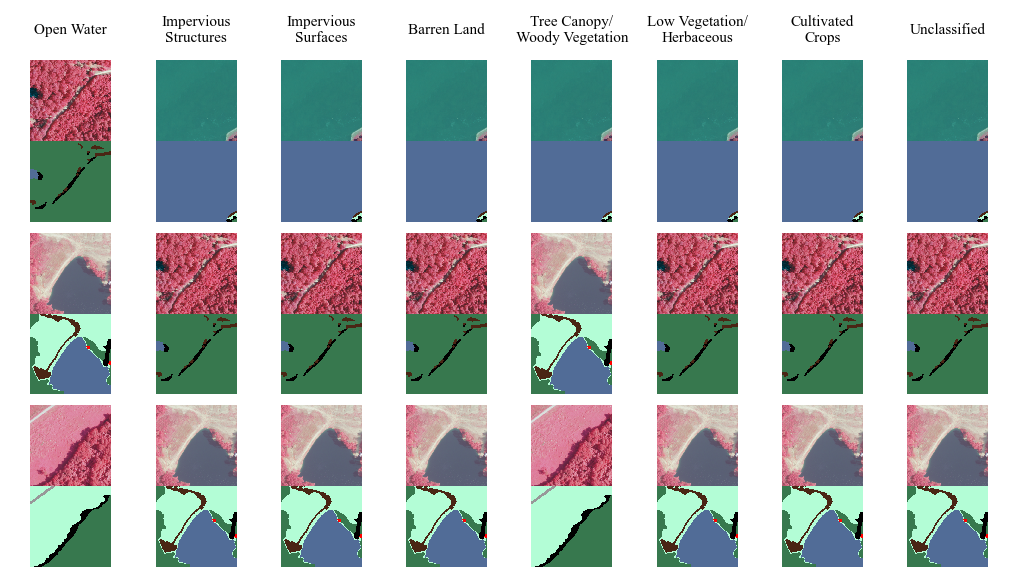

In [8]:
# ...existing code...
# layout: each cell is a 2x1 subgrid (input above label) with a dedicated title row
n_rows = 3
fig2 = plt.figure(figsize=(n_cols * 1.3, n_rows * 2))
# add one extra top row for column titles (smaller height)
height_ratios = [0.25] + [1.0] * n_rows
gs = fig2.add_gridspec(n_rows + 1, n_cols, height_ratios=height_ratios, hspace=0.08, wspace=0.03)

# create title axes (one per column) and style them
title_axes = []
for j, cid in enumerate(classes):
    ax_t = fig2.add_subplot(gs[0, j])
    ax_t.axis('off')  # no ticks / frame
    ax_t.text(0.5, 0.5, LEGEND_CLASSES[cid], ha='center', va='center',
              fontsize=11, wrap=True, family=plt.rcParams['font.family'])
    title_axes.append(ax_t)

# For each class, precompute a ranked candidate list across entire gdf
for j, cid in enumerate(classes):
    pct_col = f"{safe_names[cid]}_pct"
    candidates = gdf.loc[~gdf['id'].isin(ignore_ids)]
    # Primary: use precomputed column if available
    ranked = []
    if pct_col in candidates.columns:
        candidates[pct_col] = pd.to_numeric(candidates.get(pct_col), errors='coerce')
        ranked_df = candidates.dropna(subset=[pct_col]).sort_values(pct_col, ascending=False).head(MAX_CANDIDATES)
        ranked = list(ranked_df.to_dict('records'))
    if not ranked:
        ranked = list(candidates.to_dict('records'))

    chosen = []
    for r in ranked:
        if len(chosen) >= n_rows:
            break
        pct_val = r.get(pct_col) if pct_col in r else None
        if pct_val is not None:
            try:
                if float(pct_val) < DOMINANCE_PCT:
                    chosen.append(r)
            except Exception:
                continue

    if len(chosen) < n_rows:
        seen_paths = {c['source_fil'] for c in chosen}
        for _, row in gdf.iterrows():
            if len(chosen) >= n_rows:
                break
            sf = row['source_fil']
            if sf in seen_paths:
                continue
            try:
                with rio.open(sf) as src_t:
                    lbl = src_t.read(1)
                    if src_t.nodata is not None:
                        valid_mask = lbl != src_t.nodata
                    else:
                        valid_mask = lbl != 0
                    total = int(np.count_nonzero(valid_mask))
                    if total == 0:
                        continue
                    class_count = int(np.count_nonzero(lbl[valid_mask] == cid))
                    pct = (class_count / total) * 100
                    if pct < DOMINANCE_PCT:
                        chosen.append(row.to_dict())
                        seen_paths.add(sf)
            except Exception:
                continue

    # Plot up to n_rows chosen tiles into column j (row i -> chosen[i])
    for i in range(n_rows):
        subgs = gs[i + 1, j].subgridspec(2, 1, hspace=0.0)
        ax_top = fig2.add_subplot(subgs[0])
        ax_bot = fig2.add_subplot(subgs[1])

        # style axes for a clean, journal-ready look
        for a in (ax_top, ax_bot):
            a.set_xticks([]); a.set_yticks([])
            a.set_frame_on(False)             # remove frame
            a.set_adjustable('box')           # for equal aspect
            a.patch.set_edgecolor('white')    # thin white gutter
            a.patch.set_linewidth(1.0)

        if i < len(chosen):
            row = chosen[i]
            target_path = row['source_fil']
            input_path = target_path
            try_paths = [
                target_path.replace(os.path.sep + 'target' + os.path.sep, os.path.sep + 'input' + os.path.sep),
                target_path.replace('/target/', '/input/'),
                target_path.replace('target', 'input')
            ]
            for p in try_paths:
                if p != target_path and os.path.exists(p):
                    input_path = p
                    break
            try:
                lbl_safe, color_lbl, img_disp = read_aligned_rgb_and_label(target_path, input_path, palette_rgb, max_lbl)
                if img_disp is not None:
                    ax_top.imshow(img_disp, interpolation='nearest', aspect='equal')
                ax_bot.imshow(color_lbl.astype('float32') / 255.0, interpolation='nearest', aspect='equal')
            except Exception:
                pass
        else:
            # empty cell: keep a subtle background so grid looks uniform
            ax_top.set_facecolor('white')
            ax_bot.set_facecolor('white')

# final layout tweaks
fig2.patch.set_facecolor('white')
fig2.tight_layout(pad=0.1)
fig2.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.02)

# save with high DPI
fig2.savefig('../paper/images/fold_sample_grid.png', dpi=600, bbox_inches='tight')
# ...existing code...

In [ ]:
# Align column titles so the title block (1 or 2 lines) is vertically centered for every column
import matplotlib.pyplot as _mpl

# find candidate top axes (those near the top of the figure) and sort left->right
top_axes = [ax for ax in fig2.axes if ax.get_position().y0 > 0.45]
if not top_axes:
    # fallback: assume every second axis is a top axis
    top_axes = fig2.axes[::2]
top_axes = sorted(top_axes, key=lambda a: a.get_position().x0)

# collect titles and clear them on axes
titles = []
for ax in top_axes:
    t = ax.get_title()
    if t:
        titles.append((ax, t))
        ax.set_title('')

if titles:
    # figure size in inches
    fig_w, fig_h = fig2.get_size_inches()

    # estimate title block height in figure coords for a given title string
    def title_height_fig(title, fontsize_pt=None, linespacing=1.2):
        lines = title.count('\n') + 1
        if fontsize_pt is None:
            fontsize_pt = _mpl.rcParams.get('axes.titlesize', 10)
            try:
                fontsize_pt = float(fontsize_pt)
            except Exception:
                fontsize_pt = 10
        # approximate height in inches (points -> inches)
        height_in = (fontsize_pt / 72.0) * lines * linespacing
        return height_in / fig_h  # convert to figure coordinate (0..1)

    heights = [title_height_fig(t) for _, t in titles]
    max_h = max(heights)
    # find the top edge (y1) of the highest top-axis
    max_y1 = max(ax.get_position().y1 for ax, _ in titles)
    # set y_fig so the center of the tallest title block sits just above max_y1
    padding = 0.005
    y_fig = min(max_y1 + (max_h / 2.0) + padding, 0.995)

    # draw each title block centered at (x_center, y_fig) with vertical alignment 'center'
    for ax, title in titles:
        bbox = ax.get_position()
        x_center = bbox.x0 + bbox.width / 2.0
        fs = _mpl.rcParams.get('axes.titlesize', 10)
        ff = _mpl.rcParams.get('font.family', None)
        fig2.text(x_center, y_fig, title, ha='center', va='center', fontsize=fs, fontfamily=ff,
                  clip_on=False, transform=fig2.transFigure)

    fig2.canvas.draw_idle()

In [2]:
# count the number of valid pixels in z:\dbcenter\products\land\ms_hires_landcover\2023.tif
import rasterio as rio
import numpy as np
from tqdm import tqdm

valid_pixels = 0
with rio.open(r'z:\dbcenter\products\land\ms_hires_landcover\2023.tif') as src:
    for window in tqdm(src.block_windows(1)):
        valid_pixels += np.count_nonzero(src.read(1, window=window[1]) != src.nodata)

2718807it [04:44, 9539.68it/s] 


In [4]:
print(f"Total valid pixels: {valid_pixels}")

print(f'{valid_pixels:,}')

Total valid pixels: 123681636985
123,681,636,985


In [16]:
from glob import glob
import os

# show range of file sizes in Z:\dbcenter\images\naip\scenes\2023\MS\ms_c\*\*_1.tif
file_sizes = []
for path in glob(r'Z:\guser\dh\NAIP_MS_2023\*\*_1m.tif'):
    try:
        size = os.path.getsize(path)
        size_gb = size / (1024 ** 3)
        file_sizes.append(size_gb)
    except Exception as e:
        raise e
        continue

In [17]:
print(f'{sum(file_sizes):.1f} GB total for {len(file_sizes)} files')  
print(f'{min(file_sizes):.3f} GB to {max(file_sizes):.3f} GB')  
print(f'{(sum(file_sizes) / len(file_sizes)):.3f} GB average')  

599.4 GB total for 82 files
3.861 GB to 13.433 GB
7.310 GB average
